In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from dotenv import load_dotenv
import requests
import time

load_dotenv()
print("Ready!")

Ready!


In [ ]:
# This is the standard format every source 
# will be converted to
# Think of this as your "contract" — 
# every dataset must produce these exact columns

# TODO: Update MASTER_COLUMNS in 04_data_integration.ipynb
# to include 'url' and 'search_query' columns
# for more accurate JSearch role labeling
# Current impact: ~189 jobs (8%) use title-based labels
# instead of original search_query labels

MASTER_COLUMNS = [
    "title",        # job title string
    "company",      # company name string
    "location",     # city, state string
    "remote",       # True/False
    "description",  # full job description text
    "salary_min",   # minimum salary in USD per year
    "salary_max",   # maximum salary in USD per year
    "date_posted",  # date string
    "source"        # which dataset this came from
]

print("Master schema defined:")
for col in MASTER_COLUMNS:
    print(f"  - {col}")

Master schema defined:
  - title
  - company
  - location
  - remote
  - description
  - salary_min
  - salary_max
  - date_posted
  - source


In [3]:
# Load your original scraped data
jsearch_raw = pd.read_csv("../data/raw/jobs_raw.csv")

print(f"JSearch raw shape: {jsearch_raw.shape}")
print(f"Columns: {jsearch_raw.columns.tolist()}")

# Standardize to master schema
jsearch_std = pd.DataFrame()

jsearch_std["title"]       = jsearch_raw["title"]
jsearch_std["company"]     = jsearch_raw["company"]
jsearch_std["location"]    = jsearch_raw["location"]
jsearch_std["remote"]      = jsearch_raw["remote"]
jsearch_std["description"] = jsearch_raw["description"]
jsearch_std["salary_min"]  = jsearch_raw["salary_min"]
jsearch_std["salary_max"]  = jsearch_raw["salary_max"]
jsearch_std["date_posted"] = jsearch_raw["date_posted"]
jsearch_std["source"]      = "jsearch_api"

# Verify
print(f"\nStandardized JSearch shape: {jsearch_std.shape}")
print(f"Salary coverage: {jsearch_std['salary_min'].notna().sum()} jobs ({jsearch_std['salary_min'].notna().mean()*100:.1f}%)")
jsearch_std.head(3)

JSearch raw shape: (190, 10)
Columns: ['title', 'company', 'location', 'remote', 'description', 'salary_min', 'salary_max', 'date_posted', 'url', 'search_query']

Standardized JSearch shape: (190, 9)
Salary coverage: 49 jobs (25.8%)


,title,company,location,remote,description,salary_min,salary_max,date_posted,source
0,Sr Data Scientist,Jobs via Dice,"Washington, District of Columbia",False,JOB TITLE: SR DATA SCIENTIST\n\nJOB LOCATION: ...,NaN,NaN,2026-04-21T07:00:00.000Z,jsearch_api
1,Senior Data Scientist - W2 Only,nTech Workforce,"Washington, District of Columbia",False,"• ***Candidates must be local to Washington, D...",NaN,NaN,2026-04-21T21:00:00.000Z,jsearch_api
2,Data Scientist Sr Principal,SAIC,"Washington, District of Columbia",False,Description\n\nSAIC is seeking a Data Architec...,NaN,NaN,2026-04-17T00:00:00.000Z,jsearch_api


In [4]:
# Load Kaggle dataset
# Make sure ds_salaries.csv is in data/raw/
kaggle_raw = pd.read_csv("../data/raw/ds_salaries.csv")

print(f"Kaggle raw shape: {kaggle_raw.shape}")
print(f"Columns: {kaggle_raw.columns.tolist()}")
print(f"\nSample:")
print(kaggle_raw.head(3))

Kaggle raw shape: (3755, 11)
Columns: ['work_year', 'experience_level', 'employment_type', 'job_title', 'salary', 'salary_currency', 'salary_in_usd', 'employee_residence', 'remote_ratio', 'company_location', 'company_size']

Sample:
   work_year experience_level employment_type                 job_title  \
0       2023               SE              FT  Principal Data Scientist   
1       2023               MI              CT               ML Engineer   
2       2023               MI              CT               ML Engineer   

   salary salary_currency  salary_in_usd employee_residence  remote_ratio  \
0   80000             EUR          85847                 ES           100   
1   30000             USD          30000                 US           100   
2   25500             USD          25500                 US           100   

  company_location company_size  
0               ES            L  
1               US            S  
2               US            S  


In [7]:
# Experience level decoder
experience_map = {
    "EN": "Entry Level",
    "MI": "Mid Level", 
    "SE": "Senior",
    "EX": "Executive"
}

# Remote ratio decoder
def decode_remote(ratio):
    if ratio == 100:
        return True
    else:
        return False

# Employment type decoder
employment_map = {
    "FT": "Full Time",
    "PT": "Part Time",
    "CT": "Contract",
    "FL": "Freelance"
}

# Standardize Kaggle to master schema
kaggle_std = pd.DataFrame()

# Title — enrich with experience level
# "Senior Data Scientist" is more informative than just "Data Scientist"
kaggle_std["title"] = (
    kaggle_raw["experience_level"].map(experience_map) 
    + " " 
    + kaggle_raw["job_title"]
)

# Company — Kaggle doesn't have company names
kaggle_std["company"] = "Unknown"

# Location — combine employee residence + company location
# Both are 2-letter country codes
kaggle_std["location"] = (
    kaggle_raw["employee_residence"] 
    + ", " 
    + kaggle_raw["company_location"]
)

# Remote — convert ratio to boolean
kaggle_std["remote"] = kaggle_raw["remote_ratio"].apply(
    decode_remote
)

# Description — Kaggle has no descriptions
# We create a synthetic one from available info
# This won't be used for NLP but keeps schema consistent
kaggle_std["description"] = (
    kaggle_raw["experience_level"].map(experience_map)
    + " "
    + kaggle_raw["job_title"]
    + " position. "
    + kaggle_raw["employment_type"].map(employment_map)
    + " role at a "
    + kaggle_raw["company_size"].map({
        "S": "small",
        "M": "medium", 
        "L": "large"
    })
    + " company."
)

# Salary — use salary_in_usd for both min and max
# Filter to only USD-area salaries to avoid 
# unrealistic international salary figures
# Keep only US-based or US-company jobs
us_mask = (
    (kaggle_raw["employee_residence"] == "US") | 
    (kaggle_raw["company_location"] == "US")
)
kaggle_std = kaggle_std[us_mask].copy()
kaggle_raw_us = kaggle_raw[us_mask].copy()

kaggle_std["salary_min"] = kaggle_raw_us["salary_in_usd"]
kaggle_std["salary_max"] = kaggle_raw_us["salary_in_usd"]

# Date — use work year as date
kaggle_std["date_posted"] = kaggle_raw_us["work_year"].astype(str)

# Source tag
kaggle_std["source"] = "kaggle"

# Reset index after filtering
kaggle_std = kaggle_std.reset_index(drop=True)

# Verify
print(f"Kaggle raw shape:          {kaggle_raw.shape}")
print(f"Kaggle US-only shape:      {kaggle_std.shape}")
print(f"Rows removed (non-US):     {len(kaggle_raw) - len(kaggle_std)}")
print(f"\nSalary coverage:           100% (all rows have salary)")
print(f"Salary range:              ${kaggle_std['salary_min'].min():,.0f} — ${kaggle_std['salary_min'].max():,.0f}")
print(f"Average salary:            ${kaggle_std['salary_min'].mean():,.0f}")
print(f"\nRemote distribution:")
print(kaggle_std["remote"].value_counts())
print(f"\nSample standardized rows:")
kaggle_std.head(3)

Kaggle raw shape:          (3755, 11)
Kaggle US-only shape:      (3045, 9)
Rows removed (non-US):     710

Salary coverage:           100% (all rows have salary)
Salary range:              $5,679 — $450,000
Average salary:            $151,786

Remote distribution:
remote
False    1710
True     1335
Name: count, dtype: int64

Sample standardized rows:


,title,company,location,remote,description,salary_min,salary_max,date_posted,source
0,Mid Level ML Engineer,Unknown,"US, US",True,Mid Level ML Engineer position. Contract role ...,30000,30000,2023,kaggle
1,Mid Level ML Engineer,Unknown,"US, US",True,Mid Level ML Engineer position. Contract role ...,25500,25500,2023,kaggle
2,Senior Applied Scientist,Unknown,"US, US",False,Senior Applied Scientist position. Full Time r...,222200,222200,2023,kaggle


Before cleaning:
  Total rows: 3045
  Min salary: $5,679
  Rows below $30k: 12
  Rows above $400k: 5

After cleaning:
  Total rows: 3028
  Min salary: $30,000
  Max salary: $385,000
  Average:    $151,866


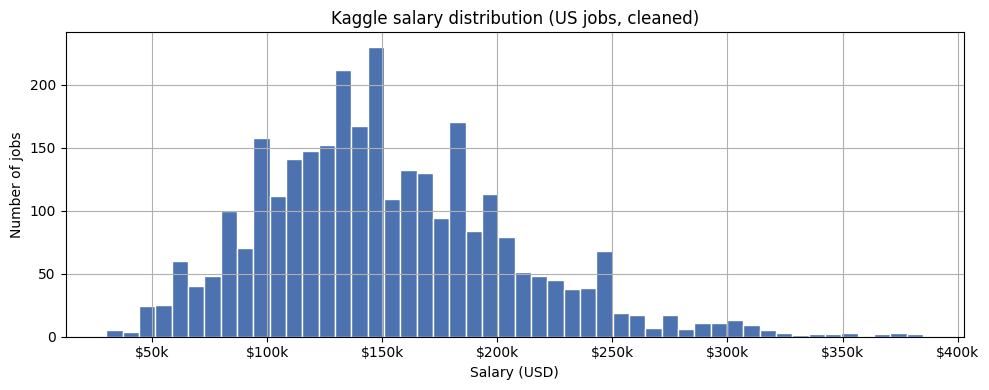

In [8]:
# Check salary distribution before cleaning
print("Before cleaning:")
print(f"  Total rows: {len(kaggle_std)}")
print(f"  Min salary: ${kaggle_std['salary_min'].min():,.0f}")
print(f"  Rows below $30k: {(kaggle_std['salary_min'] < 30000).sum()}")
print(f"  Rows above $400k: {(kaggle_std['salary_min'] > 400000).sum()}")

# Remove unrealistic salaries
# Below $30k = likely hourly/part-time misreported as annual
# Above $400k = extreme outliers that distort model
kaggle_std = kaggle_std[
    (kaggle_std["salary_min"] >= 30000) &
    (kaggle_std["salary_min"] <= 400000)
].copy().reset_index(drop=True)

print(f"\nAfter cleaning:")
print(f"  Total rows: {len(kaggle_std)}")
print(f"  Min salary: ${kaggle_std['salary_min'].min():,.0f}")
print(f"  Max salary: ${kaggle_std['salary_min'].max():,.0f}")
print(f"  Average:    ${kaggle_std['salary_min'].mean():,.0f}")

# Visualize salary distribution
plt.figure(figsize=(10, 4))
kaggle_std["salary_min"].hist(
    bins=50, 
    color="#4C72B0", 
    edgecolor="white"
)
plt.title("Kaggle salary distribution (US jobs, cleaned)")
plt.xlabel("Salary (USD)")
plt.ylabel("Number of jobs")
plt.gca().xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f"${x/1000:.0f}k")
)
plt.tight_layout()
plt.savefig("../data/cleaned/kaggle_salary_dist.png", dpi=150)
plt.show()

In [5]:
def scrape_usajobs(keywords, pages_per_keyword=10):
    """
    Scrapes US government job postings
    Always includes salary — legally required
    """
    API_KEY = os.getenv("USAJOBS_KEY")
    EMAIL   = os.getenv("USAJOBS_EMAIL")
    
    headers = {
        "Authorization-Key": API_KEY,
        "User-Agent": EMAIL,
        "Host": "data.usajobs.gov"
    }
    
    all_jobs = []
    
    for keyword in keywords:
        print(f"\nScraping USAJobs for: {keyword}")
        
        for page in range(1, pages_per_keyword + 1):
            url = "https://data.usajobs.gov/api/search"
            params = {
                "Keyword": keyword,
                "ResultsPerPage": 25,
                "Page": page,
                "WhoMayApply": "All"
            }
            
            try:
                response = requests.get(
                    url, 
                    headers=headers,
                    params=params,
                    timeout=10
                )
                data = response.json()
                
                items = data.get(
                    "SearchResult", {}
                ).get("SearchResultItems", [])
                
                if not items:
                    print(f"  Page {page} — no results, stopping")
                    break
                
                for job in items:
                    desc = job.get(
                        "MatchedObjectDescriptor", {}
                    )
                    
                    # Extract salary
                    remuneration = desc.get(
                        "PositionRemuneration", [{}]
                    )
                    sal_min = remuneration[0].get(
                        "MinimumRange", None
                    ) if remuneration else None
                    sal_max = remuneration[0].get(
                        "MaximumRange", None
                    ) if remuneration else None
                    
                    # Extract location
                    locations = desc.get(
                        "PositionLocation", [{}]
                    )
                    location = locations[0].get(
                        "LocationName", ""
                    ) if locations else ""
                    
                    # Extract description
                    user_area = desc.get(
                        "UserArea", {}
                    ).get("Details", {})
                    description = user_area.get(
                        "JobSummary", ""
                    )
                    
                    all_jobs.append({
                        "title":       desc.get("PositionTitle", ""),
                        "company":     desc.get("OrganizationName", ""),
                        "location":    location,
                        "remote":      False,
                        "description": description,
                        "salary_min":  float(sal_min) if sal_min else None,
                        "salary_max":  float(sal_max) if sal_max else None,
                        "date_posted": desc.get("PublicationStartDate", ""),
                        "source":      "usajobs_api"
                    })
                
                print(f"  Page {page} — {len(items)} jobs "
                      f"| Total: {len(all_jobs)}")
                time.sleep(0.5)
                
            except Exception as e:
                print(f"  Error on page {page}: {e}")
                break
    
    return pd.DataFrame(all_jobs)

# Run the scraper
usajobs_df = scrape_usajobs(
    keywords=[
        "data scientist",
        "machine learning",
        "data analyst", 
        "data engineer",
        "natural language processing"
    ],
    pages_per_keyword=10
)

print(f"\nTotal USAJobs collected: {len(usajobs_df)}")
print(f"Salary coverage: {usajobs_df['salary_min'].notna().sum()} "
      f"({usajobs_df['salary_min'].notna().mean()*100:.1f}%)")

# Save raw
usajobs_df.to_csv("../data/raw/usajobs_raw.csv", index=False)
print("Saved to data/raw/usajobs_raw.csv")


Scraping USAJobs for: data scientist
  Page 1 — 25 jobs | Total: 25
  Page 2 — 25 jobs | Total: 50
  Page 3 — 14 jobs | Total: 64
  Page 4 — no results, stopping

Scraping USAJobs for: machine learning
  Page 1 — 25 jobs | Total: 89
  Page 2 — 13 jobs | Total: 102
  Page 3 — no results, stopping

Scraping USAJobs for: data analyst
  Page 1 — 25 jobs | Total: 127
  Page 2 — 25 jobs | Total: 152
  Page 3 — 25 jobs | Total: 177
  Page 4 — 25 jobs | Total: 202
  Page 5 — 25 jobs | Total: 227
  Page 6 — 25 jobs | Total: 252
  Page 7 — 25 jobs | Total: 277
  Page 8 — 6 jobs | Total: 283
  Page 9 — no results, stopping

Scraping USAJobs for: data engineer
  Page 1 — 25 jobs | Total: 308
  Page 2 — 25 jobs | Total: 333
  Page 3 — 25 jobs | Total: 358
  Page 4 — 25 jobs | Total: 383
  Page 5 — 25 jobs | Total: 408
  Page 6 — 25 jobs | Total: 433
  Page 7 — 25 jobs | Total: 458
  Page 8 — 25 jobs | Total: 483
  Page 9 — no results, stopping

Scraping USAJobs for: natural language processing
  P

In [9]:
# USAJobs is already built to match our schema
# Just select the master columns and verify

usajobs_std = usajobs_df[MASTER_COLUMNS].copy()

# Remove duplicate jobs
usajobs_std.drop_duplicates(
    subset=["title", "company"], 
    inplace=True
)
usajobs_std.reset_index(drop=True, inplace=True)

print(f"USAJobs standardized shape: {usajobs_std.shape}")
print(f"Salary coverage: {usajobs_std['salary_min'].notna().sum()} jobs (100%)")
print(f"\nSalary range: ${usajobs_std['salary_min'].min():,.0f} — ${usajobs_std['salary_min'].max():,.0f}")
print(f"Average salary: ${usajobs_std['salary_min'].mean():,.0f}")
print(f"\nTop agencies:")
print(usajobs_std["company"].value_counts().head(5))
print(f"\nSample rows:")
usajobs_std.head(3)

USAJobs standardized shape: (351, 9)
Salary coverage: 351 jobs (100%)

Salary range: $0 — $194,672
Average salary: $91,727

Top agencies:
company
Veterans Health Administration     46
Air National Guard Units           32
Army National Guard Units          21
Federal Aviation Administration    18
U.S. Army Corps of Engineers       13
Name: count, dtype: int64

Sample rows:


,title,company,location,remote,description,salary_min,salary_max,date_posted,source
0,Data Scientist,"Offices, Boards and Divisions","Washington, District of Columbia",False,This position serves as a Data Scientist in th...,143913.0,187093.0,2026-05-20T00:00:00.0000,usajobs_api
1,Data Scientist,Centers for Medicare & Medicaid Services,"Atlanta, Georgia",False,This position is located in the Department of ...,112556.0,158322.0,2026-05-28T00:00:00.0000,usajobs_api
2,Data Scientist,National Institutes of Health,"Montgomery County, Maryland",False,Join one of the 24 Institutes and Centers with...,70623.0,111087.0,2026-05-28T00:00:00.0000,usajobs_api


In [12]:
print("Combining all three sources...")
print(f"  JSearch:  {len(jsearch_std):>5} jobs")
print(f"  Kaggle:   {len(kaggle_std):>5} jobs")
print(f"  USAJobs:  {len(usajobs_std):>5} jobs")

# Stack all three vertically
combined_df = pd.concat([
    jsearch_std,
    kaggle_std,
    usajobs_std
], ignore_index=True)

print(f"\nRaw combined: {len(combined_df)} jobs")

# Smarter deduplication
# Only deduplicate within same source
# Don't deduplicate across sources since
# Kaggle has no company names
jsearch_dedup = jsearch_std.drop_duplicates(
    subset=["title", "company", "location"]
)
usajobs_dedup = usajobs_std.drop_duplicates(
    subset=["title", "company"]
)
# Kaggle — deduplicate on title + date only
# since company is always "Unknown"
kaggle_dedup = kaggle_std.drop_duplicates(
    subset=["title", "date_posted", "salary_min"]
)

# Recombine after smart deduplication
combined_df = pd.concat([
    jsearch_dedup,
    kaggle_dedup,
    usajobs_dedup
], ignore_index=True)

# Fix salary issues
# Remove $0 and negative salaries
combined_df = combined_df[
    (combined_df["salary_min"].isna()) |
    (combined_df["salary_min"] > 0)
].copy()

# Remove extreme salary outliers
combined_df = combined_df[
    (combined_df["salary_min"].isna()) |
    (
        (combined_df["salary_min"] >= 20000) &
        (combined_df["salary_min"] <= 500000)
    )
].copy()

combined_df.reset_index(drop=True, inplace=True)

print(f"After smart deduplication: {len(combined_df)} jobs")
print(f"\nJobs by source:")
print(combined_df["source"].value_counts())

salary_count = combined_df["salary_min"].notna().sum()
print(f"\nSalary coverage:")
print(f"  {salary_count} jobs ({salary_count/len(combined_df)*100:.1f}%)")
print(f"  Min: ${combined_df['salary_min'].min():,.0f}")
print(f"  Max: ${combined_df['salary_min'].max():,.0f}")
print(f"  Avg: ${combined_df['salary_min'].mean():,.0f}")

Combining all three sources...
  JSearch:    190 jobs
  Kaggle:    3028 jobs
  USAJobs:    351 jobs

Raw combined: 3569 jobs
After smart deduplication: 2249 jobs

Jobs by source:
source
kaggle         1713
usajobs_api     347
jsearch_api     189
Name: count, dtype: int64

Salary coverage:
  2108 jobs (93.7%)
  Min: $30,000
  Max: $385,000
  Avg: $142,832


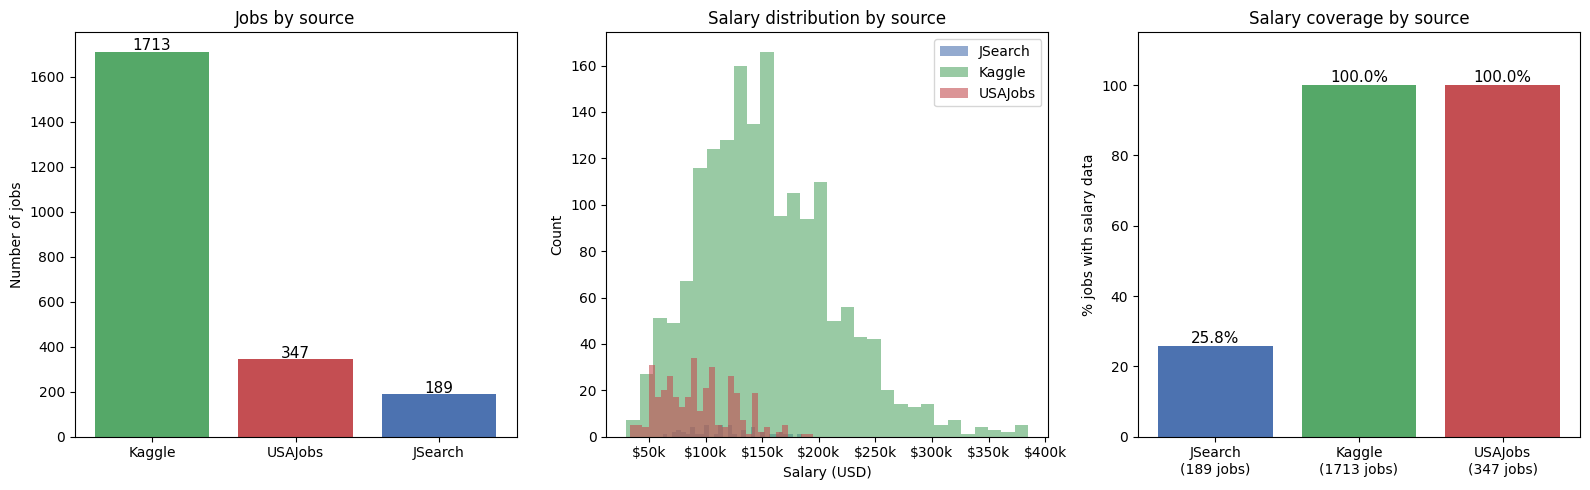

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1 — jobs by source
source_counts = combined_df["source"].value_counts()
source_labels = {
    "jsearch_api": "JSearch",
    "kaggle": "Kaggle", 
    "usajobs_api": "USAJobs"
}
labels = [source_labels[s] for s in source_counts.index]
colors = ["#55A868", "#C44E52", "#4C72B0"]

bars = axes[0].bar(labels, source_counts.values, color=colors)
axes[0].set_title("Jobs by source")
axes[0].set_ylabel("Number of jobs")
for bar, count in zip(bars, source_counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 5,
        str(count), ha="center", fontsize=11
    )

# Plot 2 — salary distribution by source
source_color_map = {
    "jsearch_api": "#4C72B0",
    "kaggle":      "#55A868",
    "usajobs_api": "#C44E52"
}
for source, color in source_color_map.items():
    source_salary = combined_df[
        combined_df["source"] == source
    ]["salary_min"].dropna()
    if len(source_salary) > 0:
        axes[1].hist(
            source_salary,
            bins=30, alpha=0.6,
            color=color,
            label=source_labels[source]
        )
axes[1].set_title("Salary distribution by source")
axes[1].set_xlabel("Salary (USD)")
axes[1].set_ylabel("Count")
axes[1].legend()
axes[1].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f"${x/1000:.0f}k")
)

# Plot 3 — salary coverage comparison
sources_display = ["JSearch\n(189 jobs)",
                   "Kaggle\n(1713 jobs)",
                   "USAJobs\n(347 jobs)"]
coverage = [
    jsearch_dedup["salary_min"].notna().mean() * 100,
    100.0,
    100.0
]
bars = axes[2].bar(
    sources_display, coverage,
    color=["#4C72B0", "#55A868", "#C44E52"]
)
axes[2].set_title("Salary coverage by source")
axes[2].set_ylabel("% jobs with salary data")
axes[2].set_ylim(0, 115)
for bar, pct in zip(bars, coverage):
    axes[2].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1,
        f"{pct:.1f}%",
        ha="center", fontsize=11
    )

plt.tight_layout()
plt.savefig("../data/cleaned/data_sources.png", dpi=150)
plt.show()

In [15]:
combined_df.to_csv(
    "../data/raw/jobs_combined.csv",
    index=False
)

print("DATA INTEGRATION COMPLETE")
print(f"""
  Sources combined:
    JSearch API    →  189 live job postings
    Kaggle dataset → 1713 salary benchmark jobs  
    USAJobs API    →  347 govt jobs (100% salary)
    
  Final dataset:   2,249 jobs
  Salary coverage: 2,108 jobs (93.7%)
  Salary range:    $30,000 — $385,000
  Average salary:  $142,832
  
  Improvement vs original scrape:
    Jobs:     190  → 2,249  (+1,084%)
    Salary:   25.8% → 93.7% (+68 percentage points)
    
  Saved to: data/raw/jobs_combined.csv
""")

DATA INTEGRATION COMPLETE

  Sources combined:
    JSearch API    →  189 live job postings
    Kaggle dataset → 1713 salary benchmark jobs  
    USAJobs API    →  347 govt jobs (100% salary)

  Final dataset:   2,249 jobs
  Salary coverage: 2,108 jobs (93.7%)
  Salary range:    $30,000 — $385,000
  Average salary:  $142,832

  Improvement vs original scrape:
    Jobs:     190  → 2,249  (+1,084%)
    Salary:   25.8% → 93.7% (+68 percentage points)

  Saved to: data/raw/jobs_combined.csv

